In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, os
sys.path.append('/content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/src')


In [3]:
import numpy as np, pandas as pd, lightgbm as lgb
import config as cf, data, predictions, evaluate

In [4]:
df = data.load()
print(len(df), 'rows')

truth_val  = evaluate.truth('val')
truth_test = evaluate.truth('test')

4850000 rows


In [5]:
# series profile
def series_features(df, cutoff):
    h = df[df['ds'] <= cutoff]
    g = h.groupby(['store_id', 'product_id'])
    f = pd.DataFrame({
        'mean_sales':  g['sale_amount'].mean(),
        'std_sales':   g['sale_amount'].std().fillna(0),
        'total_sales': g['sale_amount'].sum(),
        'zero_frac':   g['sale_amount'].apply(lambda s: (s == 0).mean()),
        'so_rate':     g['stock_hour6_22_cnt'].apply(lambda s: (s > 0).mean()),
        'so_hours':    g['stock_hour6_22_cnt'].mean(),
        'discount':    g['discount'].mean()})
    f['CV2'] = ((f['std_sales'] / f['mean_sales'].replace(0, np.nan)) ** 2).fillna(0)
    cats = (df[['store_id', 'product_id'] + cf.STATIC]
            .drop_duplicates(['store_id', 'product_id'])
            .set_index(['store_id', 'product_id']))
    return f.join(cats)

def per_series_wape(pred, truth):
    m = pred.merge(truth, on=['store_id', 'product_id', 'dt'], how='inner')
    g = m.groupby(['store_id', 'product_id'])
    err = g.apply(lambda x: (x.prediction - x.sale_amount).abs().sum(), include_groups=False)
    act = g['sale_amount'].sum()
    return (err / act)[act > 0]

def labels(pred_raw, pred_rec, truth):
    w = pd.concat([per_series_wape(pred_raw, truth).rename('raw'),
                   per_series_wape(pred_rec, truth).rename('rec')], axis=1).dropna()
    return (w['rec'] < w['raw']).astype(int)

X_train = series_features(df, cf.TUNE_TRAIN_END)     # to learn  (<= 06-18)
X_apply = series_features(df, cf.VAL_END)            # to apply  (<= 06-25)

In [6]:
# route one model and score the output
def run_router(system):
    val_raw  = pd.read_parquet(f'{cf.PRED_VAL}/{system}__raw.parquet')
    val_rec  = pd.read_parquet(f'{cf.PRED_VAL}/{system}__recovered.parquet')
    test_raw = pd.read_parquet(f'{cf.PRED_TEST}/{system}__raw.parquet')
    test_rec = pd.read_parquet(f'{cf.PRED_TEST}/{system}__recovered.parquet')

    # learn on the validation week
    y = labels(val_raw, val_rec, truth_val)
    idx = X_train.index.intersection(y.index)
    clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                             verbosity=-1, random_state=cf.SEED).fit(X_train.loc[idx], y.loc[idx])

    # apply to the test week
    choice = pd.Series(np.where(clf.predict(X_apply) == 1, 'recovered', 'raw'),
                       index=X_apply.index, name='chosen')

    oracle_lab = labels(test_raw, test_rec, truth_test)
    oracle = pd.Series(np.where(oracle_lab == 1, 'recovered', 'raw'), index=oracle_lab.index)
    common = choice.index.intersection(oracle.index)

    def pick(ch):
        a = pd.concat([test_raw.assign(input='raw'), test_rec.assign(input='recovered')])
        m = a.merge(ch.rename('chosen').reset_index(), on=['store_id', 'product_id'], how='inner')
        return m[m['input'] == m['chosen']][['store_id', 'product_id', 'dt', 'prediction']]

    def wape_of(pred):
        m = pred.merge(truth_test, on=['store_id', 'product_id', 'dt'], how='inner')
        return round((m.prediction - m.sale_amount).abs().sum() / m.sale_amount.sum(), 4)

    row = {'system': system,
           'uniform_raw': wape_of(pick(pd.Series('raw', index=common))),
           'uniform_rec': wape_of(pick(pd.Series('recovered', index=common))),
           'router':      wape_of(pick(choice.loc[common])),
           'oracle':      wape_of(pick(oracle.loc[common])),
           'n_series':    len(common)}
    row['routing_gain'] = round(row['uniform_rec'] - row['router'], 4)

    return row, clf, choice, common, pick

In [ ]:
# router features
imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
imp.to_csv(f'{cf.EVALUATION}/router_feature_importance.csv', header=['importance'])
print(imp.to_string())

discount               1381
third_category_id      1075
so_hours               1046
CV2                    1006
mean_sales              937
std_sales               911
so_rate                 765
city_id                 558
second_category_id      452
zero_frac               376
first_category_id       374
management_group_id     119
total_sales               0


In [ ]:
# series analysis -  effect of recovery on validation week (TFT)
import evaluate as ev

truth_val = ev.truth('val')

def per_series_wape(pred, truth):
    m = pred.merge(truth, on=['store_id', 'product_id', 'dt'], how='inner')
    g = m.groupby(['store_id', 'product_id'])
    err = g.apply(lambda x: (x.prediction - x.sale_amount).abs().sum(), include_groups=False)
    act = g['sale_amount'].sum()
    return (err / act)[act > 0]

val_raw = pd.read_parquet(f'{cf.PRED_VAL}/TFT__raw.parquet')
val_rec = pd.read_parquet(f'{cf.PRED_VAL}/TFT__recovered.parquet')

w = pd.concat([per_series_wape(val_raw, truth_val).rename('raw'),
               per_series_wape(val_rec, truth_val).rename('rec')], axis=1).dropna()
w['gain'] = w['raw'] - w['rec']

print(f"series      : {len(w):,}")
print(f"helped      : {(w.gain > 0).sum():,}  ({(w.gain > 0).mean():.1%})")
print(f"hurt        : {(w.gain < 0).sum():,}  ({(w.gain < 0).mean():.1%})")
print(f"median gain : {w.gain.median():+.4f}")
print(f"5th, 95th   : {w.gain.quantile(.05):+.4f}, {w.gain.quantile(.95):+.4f}")

series      : 48,077
helped      : 27,785  (57.8%)
hurt        : 20,288  (42.2%)
median gain : +0.0154
5th, 95th   : -0.2869, +0.2178


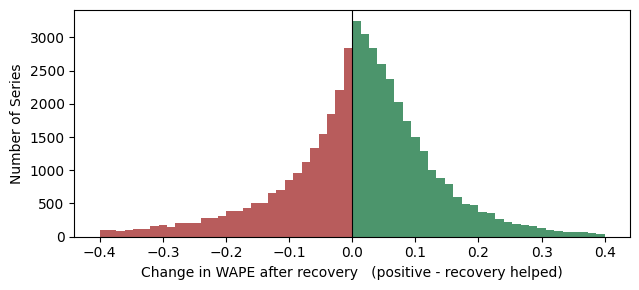

In [ ]:
RAW = '#B85C5C'   # recovery hurt
REC = '#4C956C'   # recovery helped
FIGDIR = f'{cf.PROJECT}/figures'

plt.figure(figsize=(6.5, 3))
counts, bins, patches = plt.hist(w['gain'], bins=60, range=(-0.4, 0.4))
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(REC if left >= 0 else RAW)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Change in WAPE after recovery   (positive - recovery helped)')
plt.ylabel('Number of Series')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_recovery_benefit.png', dpi=300)
plt.show()

In [ ]:
# prediction , demand distribution
truth_test = ev.truth('test')

rows = []
for m in ['LightGBM', 'TFT', 'TimesFM', 'Chronos2', 'TFT_baseline']:
    p = pd.read_parquet(f'{cf.PRED_TEST}/{m}__recovered.parquet')
    j = p.merge(truth_test, on=['store_id', 'product_id', 'dt'], how='inner')
    rows.append({'model': m,
                 'mean pred': round(j.prediction.mean(), 3),
                 'p99 pred':  round(j.prediction.quantile(.99), 2),
                 'max pred':  round(j.prediction.max(), 2)})

tail = pd.DataFrame(rows)
print(tail.to_string(index=False))
print(f"\nactual: mean {j.sale_amount.mean():.3f}   "
      f"p99 {j.sale_amount.quantile(.99):.2f}   max {j.sale_amount.max():.2f}")

       model  mean pred  p99 pred  max pred
    LightGBM      1.246      6.82     37.05
         TFT      1.286      7.40     46.39
     TimesFM      1.238      7.08     44.15
    Chronos2      1.262      7.33     45.68
TFT_baseline      1.242      7.36     39.30

actual: mean 1.237   p99 8.20   max 49.90


In [ ]:
# score on the three reported metrics
import numpy as np
import evaluate as ev, data

_, MSE_S = ev.scale_factors(data.load(),'test')     # seasonal-naive scale

def score(pred):
    m = pred.merge(truth_test, on=['store_id', 'product_id', 'dt'], how='inner')
    uid = m['store_id'].astype(str) + '_' + m['product_id'].astype(str)
    err = m['prediction'] - m['sale_amount']
    per_sq = (err ** 2).groupby(uid).mean()
    return {'WAPE':  round(err.abs().sum() / m['sale_amount'].sum(), 4),
            'WPE':   round(err.sum() / m['sale_amount'].sum(), 4),
            'RMSSE': round(np.sqrt((per_sq / MSE_S.reindex(per_sq.index)).dropna()).median(), 4)}

In [ ]:
# router metrics
rows = []
for m in ['TFT', 'LightGBM', 'TimesFM']:
    _, clf, choice, common, pick = run_router(m)
    full = choice                      # every series, not just those with a label
    for name, ch in [('uniform raw',       pd.Series('raw', index=full.index)),
                     ('uniform recovered', pd.Series('recovered', index=full.index)),
                     ('router',            full)]:
        rows.append({'model': m, 'system': name, 'n': len(ch), **score(pick(ch))})

print(pd.DataFrame(rows).to_string(index=False))

   model            system     n   WAPE     WPE  RMSSE
     TFT       uniform raw 50000 0.2947 -0.0552 0.6638
     TFT uniform recovered 50000 0.2865  0.0393 0.6667
     TFT            router 50000 0.2789  0.0116 0.6488
LightGBM       uniform raw 50000 0.3230 -0.1042 0.6812
LightGBM uniform recovered 50000 0.2951  0.0071 0.6709
LightGBM            router 50000 0.2902 -0.0193 0.6560
 TimesFM       uniform raw 50000 0.3045 -0.0858 0.6633
 TimesFM uniform recovered 50000 0.2895  0.0011 0.6664
 TimesFM            router 50000 0.2831 -0.0232 0.6444


In [ ]:
_, clf, choice, common, pick = run_router('TFT')
print(f"recovered : {(choice=='recovered').sum():,}  ({(choice=='recovered').mean():.1%})")
print(f"raw       : {(choice=='raw').sum():,}  ({(choice=='raw').mean():.1%})")

recovered : 33,260  (66.5%)
raw       : 16,740  (33.5%)


In [ ]:
# bootstrap the routing gain
import numpy as np

_, clf, choice, common, pick = run_router('TFT')

def per_series_totals(pred):
    m = pred.merge(truth_test, on=['store_id', 'product_id', 'dt'], how='inner')
    uid = m['store_id'].astype(str) + '_' + m['product_id'].astype(str)
    return pd.DataFrame({
        'abs_err': (m['prediction'] - m['sale_amount']).abs().groupby(uid).sum(),
        'sales':   m['sale_amount'].groupby(uid).sum(),
    })

rec = per_series_totals(pick(pd.Series('recovered', index=choice.index)))
rtr = per_series_totals(pick(choice))

j = rec.join(rtr['abs_err'].rename('err_router'), how='inner')
E_rec, E_rtr, S = (j['abs_err'].to_numpy(), j['err_router'].to_numpy(), j['sales'].to_numpy())

rng, n = np.random.default_rng(cf.SEED), len(j)
deltas = np.empty(1000)
for b in range(1000):
    i = rng.integers(0, n, n)                 # resample series with replacement
    s = S[i].sum()
    deltas[b] = E_rtr[i].sum() / s - E_rec[i].sum() / s

lo, hi = np.percentile(deltas, [2.5, 97.5])
print(f"series      : {n:,}")
print(f"mean delta  : {deltas.mean():+.5f}   (negative = router better)")
print(f"95% interval: {lo:+.5f} to {hi:+.5f}")

pd.DataFrame([{'comparison': 'router vs uniform recovered',
               'delta': round(deltas.mean(), 5), 'ci_low': round(lo, 5),
               'ci_high': round(hi, 5), 'resamples': 1000}]
            ).to_csv(f'{cf.EVALUATION}/bootstrap_routing.csv', index=False)

series      : 50,000
mean delta  : -0.00756   (negative = router better)
95% interval: -0.00809 to -0.00704


In [7]:
#router gain by sales tier
import evaluate as ev, config as cf

hist = df[df['ds'] <= cf.VAL_END]
mean_sales = hist.groupby(['store_id', 'product_id'])['sale_amount'].mean()
tier = pd.qcut(mean_sales, [0, 1/3, 2/3, 1.0], labels=['low', 'medium', 'high'])

_, clf, choice, common, pick = run_router('TFT')

def wape_by_tier(pred):
    m = pred.merge(truth_test, on=['store_id', 'product_id', 'dt'], how='inner')
    m = m.join(tier.rename('tier'), on=['store_id', 'product_id'])
    g = m.groupby('tier', observed=True)
    return (g.apply(lambda x: (x.prediction - x.sale_amount).abs().sum(),
                    include_groups=False) / g['sale_amount'].sum()) * 100

out = pd.DataFrame({
    'uniform raw':       wape_by_tier(pick(pd.Series('raw', index=choice.index))),
    'uniform recovered': wape_by_tier(pick(pd.Series('recovered', index=choice.index))),
    'router':            wape_by_tier(pick(choice)),
})
out['recovery gain'] = out['uniform raw'] - out['uniform recovered']
out['routing gain']  = out['uniform recovered'] - out['router']
out['series'] = tier.value_counts().reindex(out.index)
print(out.round(2).to_string())

        uniform raw  uniform recovered  router  recovery gain  routing gain  series
tier                                                                               
low       40.759998          41.299999   40.00          -0.55          1.31   16673
medium    35.889999          35.639999   34.84           0.25          0.80   16662
high      24.680000          23.350000   22.74           1.33          0.62   16665


In [8]:
# router gain by stockout severity
so_rate = hist.groupby(['store_id','product_id'])['stock_hour6_22_cnt'].apply(lambda s: (s > 0).mean())
sev = pd.qcut(so_rate, [0, 1/3, 2/3, 1.0], labels=['light', 'moderate', 'heavy'])

def wape_by(pred, grp):
    m = pred.merge(truth_test, on=['store_id','product_id','dt'], how='inner')
    m = m.join(grp.rename('g'), on=['store_id','product_id'])
    g = m.groupby('g', observed=True)
    return (g.apply(lambda x: (x.prediction - x.sale_amount).abs().sum(),
                    include_groups=False) / g['sale_amount'].sum()) * 100

out = pd.DataFrame({
    'uniform raw':       wape_by(pick(pd.Series('raw', index=choice.index)), sev),
    'uniform recovered': wape_by(pick(pd.Series('recovered', index=choice.index)), sev),
    'router':            wape_by(pick(choice), sev),
})
out['recovery gain'] = out['uniform raw'] - out['uniform recovered']
out['routing gain']  = out['uniform recovered'] - out['router']
print(out.round(2).to_string())

          uniform raw  uniform recovered     router  recovery gain  routing gain
g                                                                               
light       35.279999          35.080002  34.369999           0.20          0.71
moderate    30.049999          29.730000  29.110001           0.32          0.61
heavy       25.469999          23.920000  23.040001           1.55          0.89


In [ ]:
# features used by series
_, clf, choice, common, pick = run_router('TFT')

split = pd.Series(clf.feature_importances_, index=X_train.columns, name='split')
gain  = pd.Series(clf.booster_.feature_importance(importance_type='gain'),
                  index=X_train.columns, name='gain')

imp = pd.concat([split, gain], axis=1).sort_values('split', ascending=False)
imp['gain_rank'] = imp['gain'].rank(ascending=False).astype(int)
print(imp.round(1).to_string())

imp.to_csv(f'{cf.EVALUATION}/router_feature_importance.csv')

                     split     gain  gain_rank
discount              1381  14417.3          3
third_category_id     1075  20647.6          1
so_hours              1046   7986.8          6
CV2                   1006   7055.0          7
mean_sales             937  10080.9          5
std_sales              911  11826.2          4
so_rate                765   6777.9          9
city_id                558   6580.7         10
second_category_id     452   6779.7          8
zero_frac              376   3198.5         12
first_category_id      374   5051.5         11
management_group_id    119  17424.9          2
total_sales              0      0.0         13


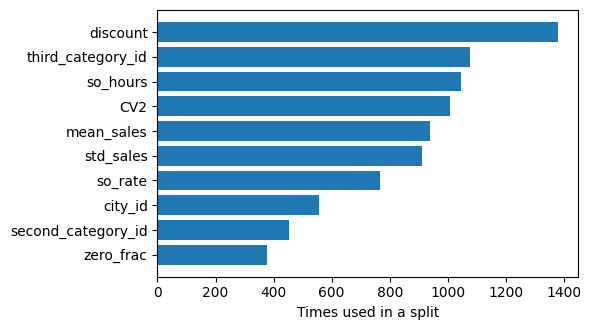

In [ ]:
import matplotlib.pyplot as plt
top = imp['split'].head(10).sort_values()
plt.figure(figsize=(6.0, 3.4))
plt.barh(top.index, top.values)
plt.xlabel('Times used in a split')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_router_importance.png', dpi=300)
plt.show()

In [ ]:
# storing the router results
rows = []
for m in ['TFT', 'LightGBM', 'TimesFM']:
    _, clf, choice, common, pick = run_router(m)
    full = choice                      # every series, not just those with a label
    for name, ch in [('uniform raw',       pd.Series('raw', index=full.index)),
                     ('uniform recovered', pd.Series('recovered', index=full.index)),
                     ('router',            full)]:
        rows.append({'model': m, 'system': name, 'n': len(ch), **score(pick(ch))})

    if m == 'TFT':                     # the model the thesis carries forward
        choice.rename('input').reset_index().to_csv(
            f'{cf.EVALUATION}/router_choice_TFT.csv', index=False)

out = pd.DataFrame(rows)
out.to_csv(f'{cf.EVALUATION}/router_by_model.csv', index=False)
print(out.to_string(index=False))

   model            system     n   WAPE     WPE  RMSSE
     TFT       uniform raw 50000 0.2947 -0.0552 0.6638
     TFT uniform recovered 50000 0.2865  0.0393 0.6667
     TFT            router 50000 0.2789  0.0116 0.6488
LightGBM       uniform raw 50000 0.3230 -0.1042 0.6812
LightGBM uniform recovered 50000 0.2951  0.0071 0.6709
LightGBM            router 50000 0.2902 -0.0193 0.6560
 TimesFM       uniform raw 50000 0.3045 -0.0858 0.6633
 TimesFM uniform recovered 50000 0.2895  0.0011 0.6664
 TimesFM            router 50000 0.2831 -0.0232 0.6444


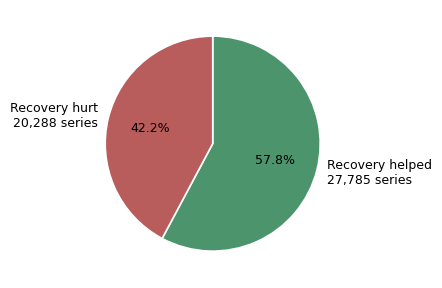

48,073 series scored of 50,000


In [ ]:

import matplotlib.pyplot as plt



RAW = '#B85C5C'   # recorded sales
REC = '#4C956C'   # recovered demand
# Cell N — how often recovery helped, validation week (TFT)
helped = int((w.gain > 0).sum())
hurt   = int((w.gain < 0).sum())
n      = helped + hurt

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.pie([helped, hurt],
       labels=[f'Recovery helped\n{helped:,} series',
               f'Recovery hurt\n{hurt:,} series'],
       colors=[REC, RAW],
       autopct='%1.1f%%',
       startangle=90,
       counterclock=False,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
       textprops={'fontsize': 9})
ax.set_aspect('equal')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig_recovery_split.png', dpi=300)
plt.show()

print(f'{n:,} series scored of 50,000')

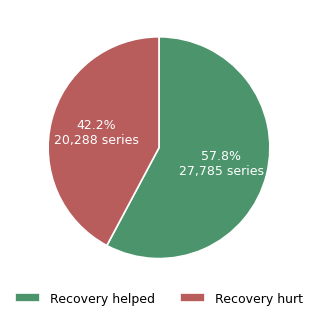

In [ ]:
# Cell N — how often recovery helped, validation week (TFT)
helped = int((w.gain > 0).sum())
hurt   = int((w.gain < 0).sum())
total  = helped + hurt

GOOD, BAD = '#4C956C' , '#B85C5C'

def lab(pct):
    return f'{pct:.1f}%\n{int(round(pct / 100 * total)):,} series'

fig, ax = plt.subplots(figsize=(3.6, 3.6))
wedges, _, _ = ax.pie(
    [helped, hurt],
    colors=[GOOD, BAD],
    autopct=lab,
    pctdistance=0.58,
    startangle=90,
    counterclock=False,
    radius=1.0,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 9, 'color': 'white'})

ax.legend(wedges, ['Recovery helped', 'Recovery hurt'],
          loc='upper center', bbox_to_anchor=(0.5, 0.02),
          ncol=2, frameon=False, fontsize=9)
ax.set_aspect('equal')
fig.savefig(f'{FIGDIR}/fig_recovery_split.png', dpi=300,
            bbox_inches='tight', pad_inches=0.02)
plt.show()

In [ ]:
# Cell N — how recovery affected each series, by model, validation week
import pandas as pd
import evaluate as ev

truth_val = ev.truth('val')

def per_series_wape(pred, truth):
    m = pred.merge(truth, on=['store_id', 'product_id', 'dt'], how='inner')
    g = m.groupby(['store_id', 'product_id'])
    err = g.apply(lambda x: (x.prediction - x.sale_amount).abs().sum(),
                  include_groups=False)
    act = g['sale_amount'].sum()
    return (err / act)[act > 0]

rows = []
for model in ['TFT', 'LightGBM', 'TimesFM']:
    raw = pd.read_parquet(f'{cf.PRED_VAL}/{model}__raw.parquet')
    rec = pd.read_parquet(f'{cf.PRED_VAL}/{model}__recovered.parquet')
    w = pd.concat([per_series_wape(raw, truth_val).rename('raw'),
                   per_series_wape(rec, truth_val).rename('rec')],
                  axis=1).dropna()
    gain = w['raw'] - w['rec']
    rows.append({'Model':        model,
                 'Series scored': len(w),
                 'Helped':       int((gain > 0).sum()),
                 'Helped %':     round((gain > 0).mean() * 100, 1),
                 'Hurt':         int((gain < 0).sum()),
                 'Hurt %':       round((gain < 0).mean() * 100, 1),
                 'Median gain':  round(gain.median(), 4)})

table = pd.DataFrame(rows)
table.to_csv(f'{cf.EVALUATION}/recovery_split_by_model.csv', index=False)
print(table.to_string(index=False))

   Model  Series scored  Helped  Helped %  Hurt  Hurt %  Median gain
     TFT          48077   27785      57.8 20288    42.2       0.0154
LightGBM          48077   26289      54.7 21788    45.3       0.0091
 TimesFM          48077   25773      53.6 22303    46.4       0.0051


In [ ]:
# Cell N — where the router sent each series, test week
row, clf, choice, common, pick = run_router('TFT')

print(choice.value_counts().to_string())
print()
print((choice.value_counts(normalize=True) * 100).round(1).to_string())

chosen
recovered    33260
raw          16740

chosen
recovered    66.5
raw          33.5


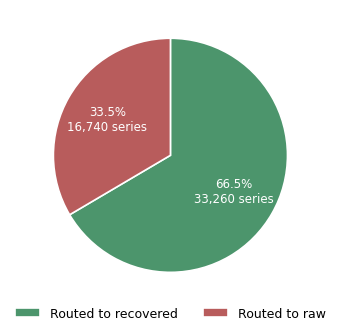

16,740 to raw, 33,260 to recovered, of 50,000


In [ ]:
# Cell N — where the router sent each series, test week (TFT)
row, clf, choice, common, pick = run_router('TFT')

n      = len(choice)
to_raw = int(choice.value_counts().get('raw', 0))
to_rec = int(choice.value_counts().get('recovered', 0))

def lab(pct):
    return f'{pct:.1f}%\n{int(round(pct / 100 * n)):,} series'

fig, ax = plt.subplots(figsize=(3.8, 3.8))
wedges, _, _ = ax.pie(
    [to_rec, to_raw],
    colors=[REC, RAW],
    autopct=lab, pctdistance=0.62,
    startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 8.5, 'color': 'white'})

ax.legend(wedges, ['Routed to recovered', 'Routed to raw'],
          loc='upper center', bbox_to_anchor=(0.5, 0.02),
          ncol=2, frameon=False, fontsize=9)
ax.set_aspect('equal')
fig.savefig(f'{FIGDIR}/fig_router_split.png', dpi=300,
            bbox_inches='tight', pad_inches=0.02)
plt.show()

print(f'{to_raw:,} to raw, {to_rec:,} to recovered, of {n:,}')